# 諸注意
- tqdmがめんどくさい
1. ターミナルにて3つをインストール

    - conda install -c conda-forge jupyter_contrib_nbextensions
    - conda install ipywidgets conda 
    - conda install -c conda-forge nodejs
 - 有効化
    - jupyter nbextension enable --py widgetsnbextension --sys-prefix

[↑バージョンがあるので注意]

    - Help > about jupyter labから自身のverを確認
    - jupyter 3.0以下の場合
    - jupyter labextension install @jupyter-widgets/jupyterlab-manager@version
    - pip install ipywidgets conda 
    
> https://www.npmjs.com/package/@jupyter-widgets/jupyterlab-manager

2. from tqdm.notebook import tqdm
   

- 自作モジュールのimportがめんどくさい
1. ipynbをpyに変換
    - ipnybファイルはインポート不可
    - terminal >  jupyter nbconvert --to python [ファイル名].ipynb

2. __init__ファイルを作成
    - モジュールをフォルダに纏める際，フォルダがライブラリと認識されるように空のファイルを作成
  
- pcapfileの修復
> https://github.com/Rup0rt/pcapfix?tab=readme-ov-file

1. git clone "url"
   - docker環境内(workspace)で実行
2. make
   - インストールしたディレクトリ内(workspace)に移動してから実施
3. make install
4. pcapファイルの修復
    - 全ファイルを修正、上書きする方法
>  for f in *.pcap; do \
  pcapfix "$f" -o "$f" \
done

5. 大量データを一括削除
> find /workspace/.... (your path) -name "*.拡張子" -type f -delete

In [1]:
"""
使用ライブラリ
"""

# pcap解析
from scapy.utils import *
from scapy.all import *
from scapy.layers.inet import *
from scapy.layers.netbios import NBNSHeader
from scapy.layers.http import HTTPRequest, HTTPResponse  # HTTPリクエストとレスポンスのインポート
import pyshark

# 並列化
import nest_asyncio
import multiprocessing
from multiprocessing import RLock, Pool, freeze_support

# 正規表現のパターンマッチングとデータの複製
import copy
import re

# 外部アプリの実行(splitcap)
import subprocess
import shutil

# pytorch を使用してonehotエンコーディングを実施
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

# システム系
import os
import json
import pathlib
import sys

# Graph作成ライブラリ
import dgl
from dgl.data import DGLDataset
from dgl import save_graphs, load_graphs

from tqdm.notebook import tqdm

# 自作ライブラリ
from dataset.data_utils.create_split import ReadAndSplitPcap
from dataset.data_utils.create_raw import ParseRawData
from dataset.data_utils.create_graph import ConstructGraph
from dataset.data_utils.raw_dataset import TrafficDataset
from dataset.data_utils.graph_dataset import GraphDataset

def main(base_dir, input_split_dir, output_raw_dir, output_graph_dir, labels_list, num_workers, dummy):

    # 分割処理
    modes = [0,1]
    split_pcap = ReadAndSplitPcap(base_dir, modes)

    # Raw Data作成
    nest_asyncio.apply()
    parser = TrafficDataset(input_split_dir, output_raw_dir, ustc_labels)
        
    # Graphの作成
    constructor = GraphDataset(input_split_dir, output_graph_dir, ustc_labels)

    freeze_support()

    # 分割処理の開始
    #split_pcap.process()
    #print("finished parse raw dataset")
    
    # rawの構築
    #parser.process()
    #print("finished create raw dataset")
    
    # グラフの構築
    constructor.process()
    print("finished create graph dataset")
    
    """
    with Pool(num_workers, initializer=tqdm.set_lock, initargs=(RLock(),)) as pool:
        pool.map(split_pcap.process, range(num_workers))
        pool.close()
        pool.join()
    print("\n" * num_workers)

    with Pool(num_workers, initializer=tqdm.set_lock, initargs=(RLock(),)) as pool:
        pool.map(parser.process, range(num_workers))
        pool.close()
        pool.join()
    print("\n" * num_workers)
    print("finished create raw dataset\n")

    with Pool(num_workers, initializer=tqdm.set_lock, initargs=(RLock(),)) as pool:
        pool.map(constructor.process, range(num_workers))
        pool.close()
        pool.join()
    print("\n" * num_workers)
    print("finished create graph dataset\n")
    """
    

if __name__ == "__main__":
    """
    パラメータ

    :dataset_dir:　分割前のデータがあるディレクトリパス
    :input_malraw_dir:　malwareのrawデータがあるディレクトリパス
    :input_benraw_dir:　benignのrawデータがあるディレクトリパス
    :output_raw_dir:　解析・成形後のrawデータを格納するディレクトリパス
    :output_graph_dir:　作成後のgraphデータを格納するディレクトリパス
    :ustc_labels:　ustcデータセット内に含まれるラベル
    :dataset_name:　データセットの名前
    """
    
    # 環境変数LD_LIBRARY_PATHを一時的に変更 
    original_ld_library_path = os.environ.get('LD_LIBRARY_PATH', '')
    os.environ['LD_LIBRARY_PATH'] = '/usr/lib/x86_64-linux-gnu:' + original_ld_library_path

    # パスの設定
    base_dir = "/workspace/dataset/ustc-tfc2016"
    input_split_dir = [os.path.join(base_dir,"split_malware"), os.path.join(base_dir,"split_benign")]
    output_raw_dir = os.path.join(base_dir,"parsed_raw")
    output_graph_dir = os.path.join(base_dir, "graph")

    dummy = [None] * 5

    num_workers = multiprocessing.cpu_count()

    # ラベルの定義
    ustc_labels = ["Cridex", "Geodo", "Htbot", "Miuref", "Virut", "Neris", "Nsis-ay", "Shifu", "Tinba", "Zeus", "Benign"]

    main(base_dir, input_split_dir, output_raw_dir, output_graph_dir, ustc_labels, num_workers, dummy)
    
    os.environ['LD_LIBRARY_PATH'] = original_ld_library_path  # 終了後、元のLD_LIBRARY_PATHに戻す



finished create graph dataset


In [8]:
import numpy as np
import os
import json

output_path = "/workspace/dataset/ustc-tfc2016/graph"
file_path = os.path.join(output_path, "meta.json")

file_list = []
double_num = 0

if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
    with open(file_path, "r") as json_file:
        flow_id_list = json.load(json_file)
    print(f"file_size:{len(flow_id_list)}")

else:
    print("no data")

for idx, file_name in enumerate(os.listdir(output_path)):
    if file_name in file_list:
        double_num +=1
        
    else:
        file_list.append(file_name)

print(f"file_size:{len(file_list)}, double_num:{double_num}")


#=================
graph_dict = {}
file_name_list = []
graph_dict_list = []
ustc_labels = ["Cridex", "Geodo", "Htbot", "Miuref", "Virut", "Neris", "Nsis-ay", "Shifu", "Tinba", "Zeus", "Benign"]
file_path = os.path.join(output_path, "meta.json")

with open(file_path, "r") as json_file:
    name2id_dict = json.load(json_file)

print(len(name2id_dict))
        
# グラフとラベルをロード
file_name_list = [path for path in os.listdir(output_path) if path.endswith('.bin')] 

for idx, file_name in enumerate(file_name_list):
    graph_path = os.path.join(output_path, file_name)
    graph, label_dict = load_graphs(graph_path)
    
    flow_id = name2id_dict[file_name]
    
    label = label_dict["label"]
    graph_dict[flow_id] = {"graph":graph, "label":label}
    graph_dict_list.append(graph_dict)

    
    #print("=========")
    label_idx = np.argmax(label, axis=0)
    #print(f"label:{ustc_labels[label_idx]}")
    #print(f"flow_id:{flow_id}, graph:{graph}, label:{label}")
    #print(graph_dict)

#==========================
input_path = "/workspace/dataset/ustc-tfc2016/parsed_raw"
data_list = []
raw_flow_id_list = []

files_name = [f for f in os.listdir(input_path) if f.endswith(".json")]
for idx, file in enumerate(files_name):
    file_path = os.path.join(input_path, file)
    with open(file_path, 'r') as json_file:
        data = json.load(json_file)
        data_list.append(data)

raw_flow_id_list = [str(data.keys()) for data in data_list]
print(f"size:{len(raw_flow_id_list)}")

file_size:60000
file_size:60001, double_num:0
60000
size:59952


<bound method DGLGraph.num_nodes of Graph(num_nodes=6, num_edges=0,
      ndata_schemes={}
      edata_schemes={})>
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
b
b
b
c
c
c


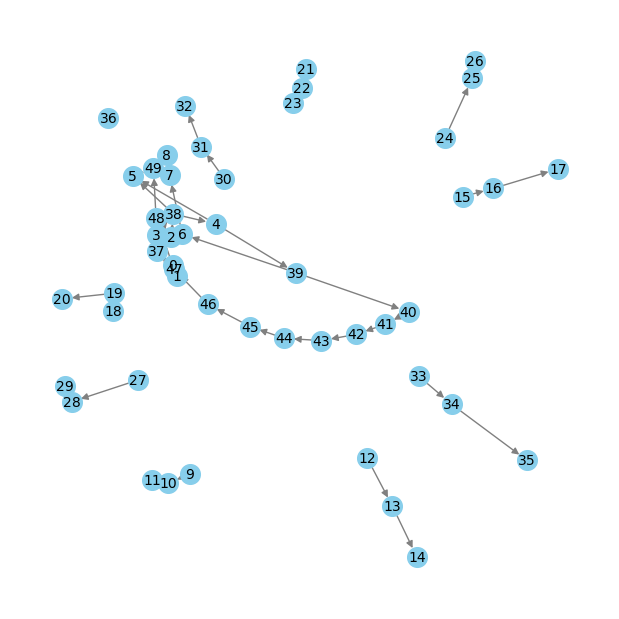

In [2]:
"""
グラフテスト
"""
import dgl
import torch
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt
import os
import random

def show_graph(g):
     # DGL グラフを NetworkX グラフに変換
    nx_graph = g.to_networkx()
    
    # グラフを描画
    pos = nx.spring_layout(nx_graph, seed=42)  # ノードの位置を決定
    plt.figure(figsize=(6,6))
    nx.draw(nx_graph, pos, with_labels=True, node_color='skyblue', edge_color='gray', node_size=200, font_size=10)
    plt.axis("off")

def connect_nodes(graph, node_list):
    length = len(node_list)
    for i in range(length-1):        
        graph.add_edges(node_list[i], node_list[i + 1])
        print("a")


def connect_lists(graph, forward_list, backward_list):
    f_len = len(forward_list)-1
    b_len = len(backward_list)-1
    max_len = max(f_len, b_len)
    min_len = min(f_len, b_len)
    
    for i in range(max_len):
        if b_len >= i and f_len >= i:
            # 先頭ノード同士を接続
            graph.add_edges(forward_list[i][0], backward_list[i][0])  
            # 末尾ノード同士を接続
            graph.add_edges(forward_list[i][-1], backward_list[i][-1])
            print("b")

    # backward_listの最後の末尾ノードと次のforward_listの先頭ノードを接続
    for i in range(max_len):
        if f_len >= i+1 and b_len >= i:
            # backward_listの先頭ノード -> 次のforward_listの先頭ノード
            graph.add_edges(backward_list[i][0], forward_list[i + 1][0])
            # backward_listの末尾ノード -> 次のforward_listの末尾ノード
            graph.add_edges(backward_list[i][-1], forward_list[i + 1][-1])
            print("c")


graph = dgl.graph(([],[]))


f_nodes = [[0, 1], [2, 3], [4, 5], [6, 7, 8], [9, 10, 11], [12, 13, 14], [15, 16, 17], [18, 19, 20], [21, 22, 23], [24, 25, 26], [27, 28, 29], [30, 31, 32], [33, 34, 35], [36]]
b_nodes = [[37], [38], [39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]]

for _ in range(6):
    graph.add_nodes(1)

print(graph.num_nodes)

for node_list in f_nodes:
    connect_nodes(graph,node_list)

for node_list in b_nodes:
    connect_nodes(graph,node_list)

connect_lists(graph, f_nodes, b_nodes)
show_graph(graph)